# Case Study: License Plate Detection & Blurring

<b>Problem statement:</b> With the growing use of cameras in traffic monitoring and surveillance, capturing vehicle images often leads to exposure of sensitive information such as license plate numbers. This raises serious privacy and data protection concerns. The objective of this project is to build an automated system using YOLOv8 to accurately detect vehicle license plates in images or video streams and blur them in real time, ensuring privacy preservation while maintaining the usefulness of the visual data for analysis and monitoring purposes.

<b>UseCase:</b> Privacy laws put legal limit on storing or sharing images with personally identifiable informations, so bluring the area containing such private information at the time of storage from the camera feed of say traffic camera footages, dash cam companies data or street view map data helps these respective companies/department.

<b>Recall vs Precision Tradeoff:</b> Here a missed plate is a privacy leak, while an extra blur on something that isnt a plate only costs a little bit of image quality. Hence recall matters more than precision.

### About Dataset <a href="https://www.kaggle.com/datasets/fareselmenshawii/large-license-plate-dataset?resource=download">(Link)</a>:
The dataset is organized into three main subsets:

- Train: This subset contains an expansive collection of ~25,500 images meticulously curated for training purposes.
- Validation (Val): With ~1,000 images, the "val" subset enables thorough model performance evaluation during development.
- Test: The "test" subset comprises ~400 images specifically reserved for post-training model evaluation.

### Environment Setup:

In [1]:
import torch
import ultralytics
import cv2
import os

print("Pytorch Version:" ,torch.__version__)
print("GPU Available?:" ,torch.cuda.is_available())
print("GPU:" ,torch.cuda.get_device_name(0))
print("CV2 Version:" ,cv2.__version__)
print("Ultralytics Version:" ,ultralytics.__version__)

Pytorch Version: 2.14.1+cu132
GPU Available?: True
GPU: NVIDIA GeForce RTX 3070
CV2 Version: 5.0.0
Ultralytics Version: 8.4.172


# Part II: Modelling (GPU)

> Sections 2-5 (data audit, coordinate conversion, bounding-box overlay, EDA) come before this part. The cells below are self-contained: they define their own paths and helpers, so Part II can be run without re-running Part I.

## 6. Model Selection

### 6.0 Why a one-stage detector (YOLOv8) instead of a two-stage detector? *(Business Q5)*

| | **Two-stage** (e.g. Faster R-CNN) | **One-stage** (YOLOv8) |
|---|---|---|
| How it works | Stage 1 proposes ~2,000 candidate regions (RPN); stage 2 classifies and refines each one | One forward pass predicts boxes and classes densely over the whole image |
| Speed | Typically 5-15 FPS on a GPU | 100+ FPS on a GPU, usable on CPU / edge devices |
| Accuracy edge | Better on crowded scenes with many overlapping classes | Small gap, and it disappears for a **single, visually distinctive class** like license plates |
| Deployment | Heavier, harder to export | One-line export to ONNX / TensorRT / CoreML |

The business requirement is **real-time anonymisation of camera streams**, ideally *at the source* (on the camera / edge box) before footage is stored or uploaded. Latency and deployability matter more than the last 1-2 points of mAP, and license plates are a single rigid, high-contrast object class: exactly where a one-stage detector loses almost nothing. YOLOv8 also has an anchor-free head (no anchor boxes to tune for the unusual 2:1-5:1 plate aspect ratio) and a mature training/export toolkit (`ultralytics`).

In [2]:
import sys, time, json, logging, random
from contextlib import contextmanager
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from PIL import Image
from ultralytics import YOLO
from ultralytics.utils import LOGGER

# ---- Paths (the only lines to change when running elsewhere, e.g. Colab) ----
IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = Path("/content/drive/MyDrive/yolo_assignment") if IN_COLAB else Path.cwd()
DATA_ROOT = Path("/content/dataset") if IN_COLAB else PROJECT_ROOT / "dataset"
WEIGHTS_DIR = PROJECT_ROOT / "weights"   # pretrained YOLOv8 checkpoints
RUNS_DIR = PROJECT_ROOT / "runs"         # training runs (weights, curves)
OUT_DIR = PROJECT_ROOT / "outputs"       # anonymised images, metrics
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "val", "test"]
IMGSZ = 640                              # model input size (longest side, see Section 7)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED)


@contextmanager
def quiet():
    """Silence Ultralytics logging and progress bars (keeps the exported PDF short)."""
    level = LOGGER.level
    LOGGER.setLevel(logging.WARNING)
    try:
        yield
    finally:
        LOGGER.setLevel(level)


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    """Normalised YOLO (centre x, centre y, width, height) -> pixel corners (x1, y1, x2, y2)."""
    return ((xc - w / 2) * img_w, (yc - h / 2) * img_h,
            (xc + w / 2) * img_w, (yc + h / 2) * img_h)


print(f"Device: {torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU'} | data: {DATA_ROOT}")

Device: NVIDIA GeForce RTX 3070 | data: c:\Users\mayan\Desktop\yolo_assignement\dataset


### 6.1 Plate characteristics that drive the model choice *(Business Q7)*

What matters for the detector is not the plate size in the original photo but **how many pixels the plate occupies after the image is resized to the model input** (640 px on the longest side). Below, every annotated plate is converted to that scale.

The file names reveal that the dataset is a merge of two sources: **Roboflow** exports (`*.rf.*`, mostly 416x416 close-ups of vehicles/motorbikes) and **Open Images** photos (16-character hex ids, ~1024 px real-world scenes).

In [3]:
def image_source(stem):
    """Roboflow exports contain '.rf.' in the file name; Open Images ids are 16 hex characters."""
    return "Roboflow" if ".rf." in stem else "Open Images"


def load_plates(split):
    """One row per annotated plate, with the image size needed to convert to pixels."""
    rows = []
    for lbl in sorted((DATA_ROOT / "labels" / split).glob("*.txt")):
        img_w, img_h = Image.open(DATA_ROOT / "images" / split / f"{lbl.stem}.jpg").size  # reads header only
        for line in lbl.read_text().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            _, xc, yc, w, h = map(float, parts)
            rows.append((split, lbl.stem, image_source(lbl.stem), img_w, img_h, xc, yc, w, h))
    return pd.DataFrame(rows, columns=["split", "file", "source", "img_w", "img_h", "xc", "yc", "w", "h"])


plates = pd.concat([load_plates(s) for s in SPLITS], ignore_index=True)
resize = IMGSZ / plates[["img_w", "img_h"]].max(axis=1)          # letterbox scale factor
plates["w_in"] = plates.w * plates.img_w * resize                 # plate width at model input (px)
plates["h_in"] = plates.h * plates.img_h * resize                 # plate height at model input (px)
plates["aspect"] = (plates.w * plates.img_w) / (plates.h * plates.img_h)

plate_summary = (plates.groupby(["split", "source"])
                 .agg(images=("file", "nunique"), plates=("file", "size"),
                      median_width_px=("w_in", "median"), median_height_px=("h_in", "median"),
                      pct_width_under_16px=("w_in", lambda s: 100 * (s < 16).mean()),
                      median_aspect=("aspect", "median"))
                 .round(1).reindex(SPLITS, level=0))
plate_summary

images  plates  median_width_px  median_height_px  \
split source                                                           
train Open Images    4295    6279             34.4              15.2   
      Roboflow      21157   21941            126.2              73.8   
val   Open Images    1073    1573             32.8              15.6   
test  Open Images     386     512             70.8              32.8   

                   pct_width_under_16px  median_aspect  
split source                                            
train Open Images                  18.5            2.1  
      Roboflow                      0.9            1.6  
val   Open Images                  19.4            2.0  
test  Open Images                  11.7            2.0

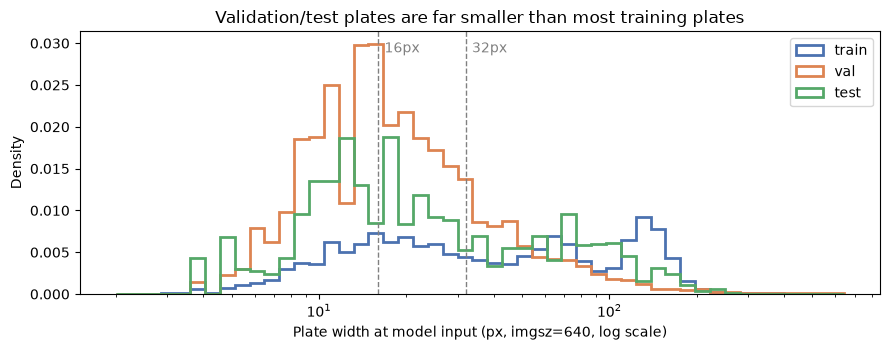

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(np.log10(2), np.log10(IMGSZ), 50)
for split, color in zip(SPLITS, ["#4C72B0", "#DD8452", "#55A868"]):
    ax.hist(plates.loc[plates.split == split, "w_in"], bins=bins, density=True,
            histtype="step", lw=2, color=color, label=split)
for px in (16, 32):
    ax.axvline(px, color="grey", ls="--", lw=1)
    ax.text(px * 1.05, ax.get_ylim()[1] * 0.92, f"{px}px", color="grey")
ax.set_xscale("log")
ax.set(xlabel=f"Plate width at model input (px, imgsz={IMGSZ}, log scale)", ylabel="Density",
       title="Validation/test plates are far smaller than most training plates")
ax.legend()
plt.tight_layout(); plt.show()

### 6.2 Speed vs. size of the YOLOv8 variants *(Business Q6)*

Latency does not depend on what the model was trained on, so the COCO-pretrained checkpoints are benchmarked directly on test images: end-to-end `predict()` time (pre-processing + inference + NMS) on the **GPU** (server / edge box with accelerator) and on the **CPU** (low-power edge device). COCO mAP is Ultralytics' published accuracy for each variant.

In [5]:
from ultralytics.utils.torch_utils import get_num_params, get_flops

COCO_MAP = {"yolov8n": 37.3, "yolov8s": 44.9, "yolov8m": 50.2}   # published COCO mAP50-95 (Ultralytics docs)


def latency_ms(model, images, device, warmup=5):
    """Mean end-to-end predict() time per image in milliseconds."""
    for img in images[:warmup]:
        model.predict(img, imgsz=IMGSZ, device=device, verbose=False)
    if device != "cpu":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for img in images:
        model.predict(img, imgsz=IMGSZ, device=device, verbose=False)
    if device != "cpu":
        torch.cuda.synchronize()
    return 1000 * (time.perf_counter() - start) / len(images)


test_paths = sorted((DATA_ROOT / "images" / "test").glob("*.jpg"))
bench_imgs = [cv2.imread(str(p)) for p in random.Random(SEED).sample(test_paths, 60)]

rows = []
for name in COCO_MAP:
    m = YOLO(WEIGHTS_DIR / f"{name}.pt")
    rows.append({"variant": name, "params_M": get_num_params(m.model) / 1e6, "GFLOPs": get_flops(m.model, IMGSZ),
                 "COCO_mAP50-95": COCO_MAP[name],
                 "GPU_ms": latency_ms(m, bench_imgs, DEVICE) if DEVICE != "cpu" else np.nan,
                 "CPU_ms": latency_ms(m, bench_imgs[:30], "cpu")})
variants = pd.DataFrame(rows).set_index("variant")
variants["GPU_FPS"] = 1000 / variants.GPU_ms
variants["CPU_FPS"] = 1000 / variants.CPU_ms
variants.round(1)

,params_M,GFLOPs,COCO_mAP50-95,GPU_ms,CPU_ms,GPU_FPS,CPU_FPS
variant,,,,,,,
yolov8n,3.2,8.9,37.3,17.0,43.3,58.9,23.1
yolov8s,11.2,28.8,44.9,16.5,84.1,60.4,11.9
yolov8m,25.9,79.3,50.2,16.7,189.3,60.0,5.3


### 6.3 Decision: YOLOv8**s** *(Business Q6, Q7)*

**Speed (table 6.2).** On the GPU all three variants run at ~16-17 ms per frame (~60 FPS): at 640 px a single frame is too small a workload to saturate the GPU, so the time is dominated by pre-processing, NMS and framework overhead rather than the network itself. Moving up from *n* to *s* to *m* is therefore almost free on a GPU. On the **CPU** the cost scales with compute (GFLOPs): *n* ~23 FPS, *s* ~12 FPS, *m* ~5 FPS.

**Accuracy.** On COCO, *s* gains +7.6 mAP over *n*, while *m* adds only +5.3 more for ~2.8x the FLOPs of *s*.

**Plate characteristics (6.1).**
* *Single, rigid, high-contrast class.* A plate is a bright rectangle with dark characters at a fairly consistent ~2:1 aspect ratio, so the appearance is simple and a very large model (*m/l/x*) is not needed to learn it.
* *Small size.* The median validation plate is only **~33 px wide** at model input and **~19% are under 16 px**. Small objects leave very few pixels of evidence, which is where the smallest model (*n*), with its thinner feature maps, loses accuracy first.
* *Large domain gap.* 83% of the training images are Roboflow close-ups (median plate width 126 px), while validation and test are entirely Open Images scenes with much smaller plates. The model needs enough capacity to cover both.

**Why *s*.** *s* is the smallest variant with comfortable capacity for small plates, it runs well above real time on a GPU (~60 FPS, 2x a 30 FPS stream) and still near real time on a CPU (~12 FPS, enough for typical 10-15 FPS traffic cameras). It also trains in ~2 h on an 8 GB GPU at batch 16, while *m* would need roughly twice the time and a smaller batch. For the small-plate problem, extra **resolution** buys more than extra depth (see 8.3), so the compute budget is better spent on keeping 640 px than on a bigger model.

*Limitation:* only *s* was trained (time budget). The *n* vs. *s* vs. *m* accuracy comparison relies on the published COCO numbers; a short fine-tune of each variant on this dataset would confirm the choice.

## 7. Training

### 7.1 Pre-processing without losing fine-grained plate detail *(Business Q4)*

* **No offline resizing or cropping.** Images stay on disk at their original resolution; all resizing happens on the fly, so nothing is lost permanently and the choice of `imgsz` can be revisited.
* **Letterbox resize to 640 px (longest side), aspect ratio preserved.** The image is scaled uniformly and padded with grey instead of being stretched to a square. Plates are wide rectangles (median aspect ~2-4:1, see 6.1); stretching would distort character shapes and the box geometry the model must learn.
* **Why 640 and not native resolution?** Roboflow images (416 px) are *up*-scaled, so they lose nothing. Open Images photos (~1024 px) are down-scaled by ~0.6, which is what makes their plates small (6.1). Training at 1024 would keep ~1.6x more pixels per plate but costs ~2.5x the compute and memory, and does not fit a useful batch size in the 8 GB of VRAM. 640 is the standard YOLOv8 resolution and the trade-off chosen here; Section 8.3 measures what it costs on the smallest plates.
* **Colour kept (3-channel RGB), pixel values scaled to 0-1.** No grayscale conversion: plate colour (white/yellow/blue backgrounds) is itself a useful cue.
* **Augmentations chosen for the train/val domain gap:**
  * *Mosaic* (4 images tiled into one): each image is shrunk ~2x, so the large Roboflow close-up plates become small, which is exactly the size seen in validation/test. Switched off for the last 5 epochs (`close_mosaic=5`) so the model finishes on realistic, un-tiled images.
  * *Random scale (+/-50%) and translation*: more plate sizes and positions.
  * *HSV jitter*: robustness to lighting, night scenes, colour casts.
  * *Horizontal flip*: allowed, because the task is to *locate* the plate, not read it, so mirrored text does not matter. No vertical flip or large rotations, since plates are almost always upright.
* **AMP (mixed precision)** halves memory use and speeds up training on the GPU, with no effect on accuracy.

In [6]:
# Ultralytics dataset config, written from the notebook so it always points at DATA_ROOT
DATA_YAML = PROJECT_ROOT / "data.yaml"
DATA_YAML.write_text(yaml.safe_dump({
    "path": str(DATA_ROOT.resolve()),
    "train": "images/train", "val": "images/val", "test": "images/test",
    "names": {0: "license_plate"},
}, sort_keys=False))
print(DATA_YAML.read_text())

path: C:\Users\mayan\Desktop\yolo_assignement\dataset
train: images/train
val: images/val
test: images/test
names:
  0: license_plate



In [7]:
RUN_NAME = "yolov8s_640"
RUN_DIR = RUNS_DIR / RUN_NAME

TRAIN_CFG = dict(
    data=str(DATA_YAML),
    epochs=30,            # ~10 min/epoch on an RTX 3070
    patience=10,          # early-stop if val fitness does not improve for 10 epochs
    imgsz=IMGSZ,
    batch=16,             # fits comfortably in 8 GB VRAM with AMP
    amp=True,
    workers=8,
    close_mosaic=5,       # last 5 epochs without mosaic (see 7.1)
    mosaic=1.0, scale=0.5, translate=0.1, fliplr=0.5, flipud=0.0, degrees=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    seed=SEED,
    device=DEVICE,
    project=str(RUNS_DIR), name=RUN_NAME, exist_ok=True,
    plots=True,
)


def training_finished(run_dir):
    """Ultralytics strips the optimizer state from last.pt once training completes."""
    last = run_dir / "weights" / "last.pt"
    return last.exists() and torch.load(last, map_location="cpu", weights_only=False).get("optimizer") is None


if training_finished(RUN_DIR):
    print(f"Trained weights found in {RUN_DIR}, skipping training.")
else:
    start = time.time()
    with quiet():  # per-epoch metrics are saved to results.csv and plotted below
        if (RUN_DIR / "weights" / "last.pt").exists():
            YOLO(RUN_DIR / "weights" / "last.pt").train(resume=True)   # continue an interrupted run
        else:
            YOLO(WEIGHTS_DIR / "yolov8s.pt").train(**TRAIN_CFG)
    (RUN_DIR / "train_time.json").write_text(json.dumps({"hours": (time.time() - start) / 3600}))

results = pd.read_csv(RUN_DIR / "results.csv")
results.columns = results.columns.str.strip()
train_hours = json.loads((RUN_DIR / "train_time.json").read_text())["hours"] if (RUN_DIR / "train_time.json").exists() else float("nan")
best = results.loc[results["metrics/mAP50-95(B)"].idxmax()]
print(f"Epochs run: {len(results)} | training time: {train_hours:.1f} h | "
      f"best epoch: {int(best.epoch)} (val mAP50 {best['metrics/mAP50(B)']:.3f}, mAP50-95 {best['metrics/mAP50-95(B)']:.3f})")

Trained weights found in c:\Users\mayan\Desktop\yolo_assignement\runs\yolov8s_640, skipping training.
Epochs run: 30 | training time: 2.1 h | best epoch: 26 (val mAP50 0.861, mAP50-95 0.468)


### 7.2 Training curves

Left: the three YOLOv8 losses (box regression, classification, distribution-focal loss for box edges) on train vs. validation. Train and val losses falling together means the model is learning, not memorising. Right: validation metrics per epoch. The dotted line marks where mosaic augmentation is switched off.

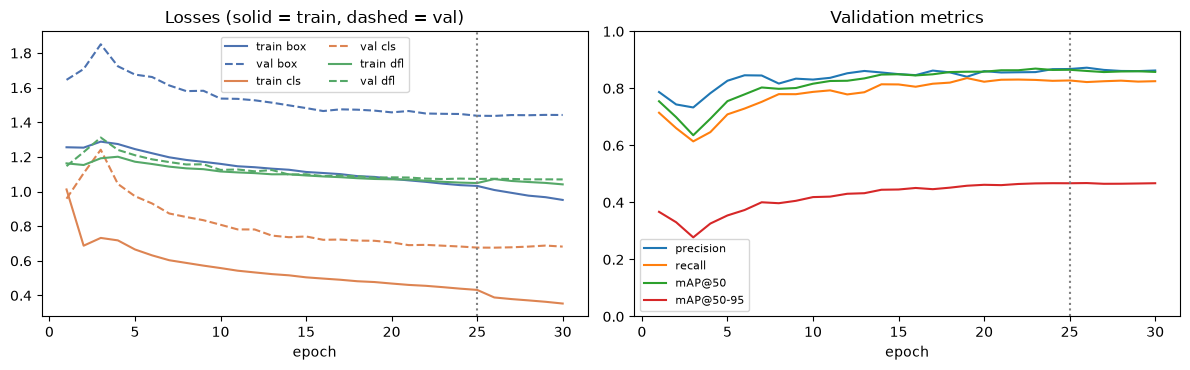

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for loss, color in zip(["box", "cls", "dfl"], ["#4C72B0", "#DD8452", "#55A868"]):
    axes[0].plot(results.epoch, results[f"train/{loss}_loss"], color=color, label=f"train {loss}")
    axes[0].plot(results.epoch, results[f"val/{loss}_loss"], color=color, ls="--", label=f"val {loss}")
axes[0].set(title="Losses (solid = train, dashed = val)", xlabel="epoch")
axes[0].legend(ncol=2, fontsize=8)

for col, label in [("metrics/precision(B)", "precision"), ("metrics/recall(B)", "recall"),
                   ("metrics/mAP50(B)", "mAP@50"), ("metrics/mAP50-95(B)", "mAP@50-95")]:
    axes[1].plot(results.epoch, results[col], label=label)
axes[1].set(title="Validation metrics", xlabel="epoch", ylim=(0, 1))
axes[1].legend(fontsize=8)
for ax in axes:
    ax.axvline(results.epoch.max() - TRAIN_CFG["close_mosaic"], color="grey", ls=":")
plt.tight_layout(); plt.show()

## 8. Evaluation

### 8.1 Standard detection metrics on validation and the held-out test set

* **Precision**: of the boxes predicted, how many are real plates.
* **Recall**: of the real plates, how many were found. **This is the privacy metric**: every missed plate is a leak.
* **mAP@50**: average precision when a prediction counts as correct at IoU >= 0.5 with the label.
* **mAP@50-95**: averaged over stricter IoU thresholds (0.5 to 0.95), so it also rewards **tight** boxes. That matters for blurring, because a loose box blurs part of the car and a box that is too small leaves part of the plate readable.

In [9]:
model = YOLO(RUN_DIR / "weights" / "best.pt")

rows = {}
for split in ["val", "test"]:
    with quiet():
        m = model.val(data=str(DATA_YAML), split=split, imgsz=IMGSZ, batch=16, device=DEVICE,
                      plots=False, verbose=False, project=str(RUNS_DIR), name=f"{RUN_NAME}_eval_{split}", exist_ok=True)
    rows[split] = {"precision": m.box.mp, "recall": m.box.mr, "mAP@50": m.box.map50, "mAP@50-95": m.box.map,
                   "inference_ms/img": m.speed["inference"], "total_ms/img": sum(m.speed.values())}
detection_metrics = pd.DataFrame(rows).T
detection_metrics.round(3)

,precision,recall,mAP@50,mAP@50-95,inference_ms/img,total_ms/img
val,0.874,0.823,0.862,0.469,3.242,5.397
test,0.918,0.893,0.915,0.661,3.614,5.569


### 8.2 Choosing the confidence threshold: favour recall *(privacy-first)*

YOLO outputs a confidence score per box, and we choose which threshold counts as a plate to blur. A low threshold blurs more (higher recall, more false blurs); a high threshold blurs less. Since **a missed plate is a privacy leak while a false blur only costs a small patch of image**, the threshold is chosen to maximise the **F2 score**, which weights recall 2x as much as precision.

The threshold is chosen on the **validation** set and then only *reported* on the test set, so the test numbers stay an honest estimate. Matching rule: a prediction is a true positive if it overlaps an unmatched labelled plate with IoU >= 0.5 (greedy, highest confidence first).

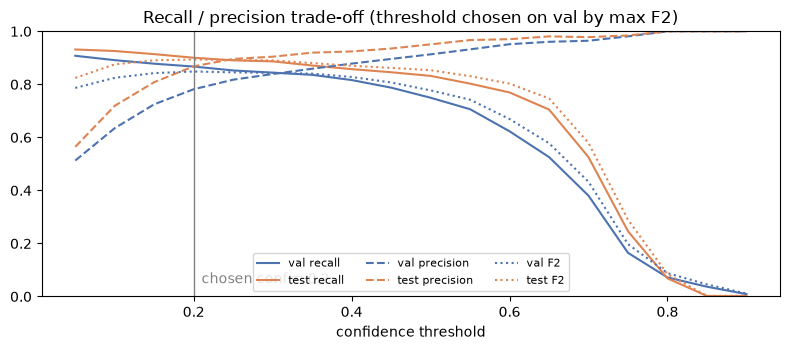

conf  precision  recall     F2  missed_plates  false_blurs
val  1  0.10      0.635   0.891  0.825            171          806
     3  0.20      0.782   0.867  0.849            209          381
     4  0.25      0.818   0.853  0.845            232          299
     9  0.50      0.913   0.750  0.777            394          112
test 1  0.10      0.719   0.926  0.876             38          185
     3  0.20      0.868   0.900  0.894             51           70
     4  0.25      0.896   0.891  0.892             56           53
     9  0.50      0.951   0.832  0.853             86           22

In [10]:
def iou_matrix(a, b):
    """Pairwise IoU between boxes a (N,4) and b (M,4) in x1y1x2y2 format."""
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area = lambda x: (x[:, 2] - x[:, 0]) * (x[:, 3] - x[:, 1])
    return inter / (area(a)[:, None] + area(b)[None, :] - inter + 1e-9)


def predict_split(split, conf=0.01):
    """Low-threshold predictions + ground truth for every image of a split."""
    gt = plates[plates.split == split]
    paths = sorted((DATA_ROOT / "images" / split).glob("*.jpg"))
    out = {}
    for path in paths:
        r = model.predict(str(path), imgsz=IMGSZ, conf=conf, device=DEVICE, verbose=False)[0]
        stem = path.stem
        g = gt[gt.file == stem]
        gt_xyxy = np.array([yolo_to_xyxy(*row) for row in g[["xc", "yc", "w", "h", "img_w", "img_h"]].values]).reshape(-1, 4)
        out[stem] = {"pred": r.boxes.xyxy.cpu().numpy(), "conf": r.boxes.conf.cpu().numpy(),
                     "gt": gt_xyxy, "gt_w_in": g.w_in.values, "shape": r.orig_shape, "speed": r.speed}
    return out


def match(pred, conf, gt, iou_thr=0.5):
    """Greedy matching. Returns per-prediction TP flags and, per GT plate, the confidence it was found at (0 = missed)."""
    order = np.argsort(-conf)
    tp = np.zeros(len(pred), bool)
    gt_conf = np.zeros(len(gt))
    if len(pred) and len(gt):
        ious = iou_matrix(pred[order], gt)
        taken = np.zeros(len(gt), bool)
        for i, row in enumerate(ious):
            row = np.where(taken, -1, row)
            j = row.argmax()
            if row[j] >= iou_thr:
                taken[j] = True; tp[order[i]] = True; gt_conf[j] = conf[order[i]]
    return tp, gt_conf


def evaluate(preds):
    confs, tps, gt_confs, gt_sizes = [], [], [], []
    for p in preds.values():
        tp, gc = match(p["pred"], p["conf"], p["gt"])
        confs.append(p["conf"]); tps.append(tp); gt_confs.append(gc); gt_sizes.append(p["gt_w_in"])
    return np.concatenate(confs), np.concatenate(tps), np.concatenate(gt_confs), np.concatenate(gt_sizes)


def pr_at(thresholds, confs, tps, gt_confs):
    rows = []
    for t in thresholds:
        keep = confs >= t
        tp, fp = tps[keep].sum(), (~tps[keep]).sum()
        recall = (gt_confs >= t).mean() if t > 0 else 1.0
        precision = tp / max(tp + fp, 1)
        f2 = 5 * precision * recall / max(4 * precision + recall, 1e-9)
        rows.append({"conf": t, "precision": precision, "recall": recall, "F2": f2,
                     "missed_plates": int((gt_confs < t).sum()), "false_blurs": int(fp)})
    return pd.DataFrame(rows)


with quiet():
    preds = {split: predict_split(split) for split in ["val", "test"]}
ev = {split: evaluate(preds[split]) for split in preds}

thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)
curve_val = pr_at(thresholds, *ev["val"][:3])
CONF = float(curve_val.loc[curve_val.F2.idxmax(), "conf"])
curve_test = pr_at(thresholds, *ev["test"][:3])

fig, ax = plt.subplots(figsize=(8, 3.6))
for col, style in [("recall", "-"), ("precision", "--"), ("F2", ":")]:
    ax.plot(curve_val.conf, curve_val[col], style, color="#4C72B0", label=f"val {col}")
    ax.plot(curve_test.conf, curve_test[col], style, color="#DD8452", label=f"test {col}")
ax.axvline(CONF, color="grey", lw=1)
ax.text(CONF + 0.01, 0.05, f"chosen conf = {CONF}", color="grey")
ax.set(xlabel="confidence threshold", ylim=(0, 1), title="Recall / precision trade-off (threshold chosen on val by max F2)")
ax.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.show()

pd.concat({"val": curve_val, "test": curve_test}).loc[lambda d: d.conf.isin([0.1, 0.25, CONF, 0.5])].round(3)

### 8.3 Recall by plate size: where does the model leak? *(Business Q7)*

Same test set, at the chosen threshold, broken down by plate width **at model input** (pixels after resizing to 640).

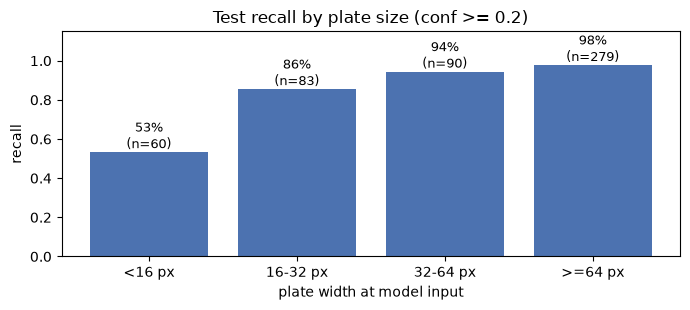

In [11]:
_, _, gt_conf_test, gt_w_test = ev["test"]
size_bins = [0, 16, 32, 64, np.inf]
size_labels = ["<16 px", "16-32 px", "32-64 px", ">=64 px"]
by_size = (pd.DataFrame({"size": pd.cut(gt_w_test, size_bins, labels=size_labels, right=False),
                         "found": gt_conf_test >= CONF})
           .groupby("size", observed=False).agg(plates=("found", "size"), recall=("found", "mean")))

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(by_size.index.astype(str), by_size.recall, color="#4C72B0")
for bar, (n, r) in zip(bars, by_size.values):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f"{r:.0%}\n(n={int(n)})", ha="center", fontsize=9)
ax.set(ylim=(0, 1.15), ylabel="recall", xlabel="plate width at model input",
       title=f"Test recall by plate size (conf >= {CONF})")
plt.tight_layout(); plt.show()

### 8.4 Error analysis: missed plates and confident false positives *(Business Q3)*

Green = labelled plate, red = prediction (with confidence). The top row shows test images with **missed** plates; the bottom row shows the **most confident false positives**. Looking at false positives is how annotation quality shows up: a confident "false positive" is often a real plate the annotator did not label, so the model is right and the label is wrong. Such errors lower the measured precision, and when the same gaps exist in training labels they teach the model to ignore real plates, which lowers recall.

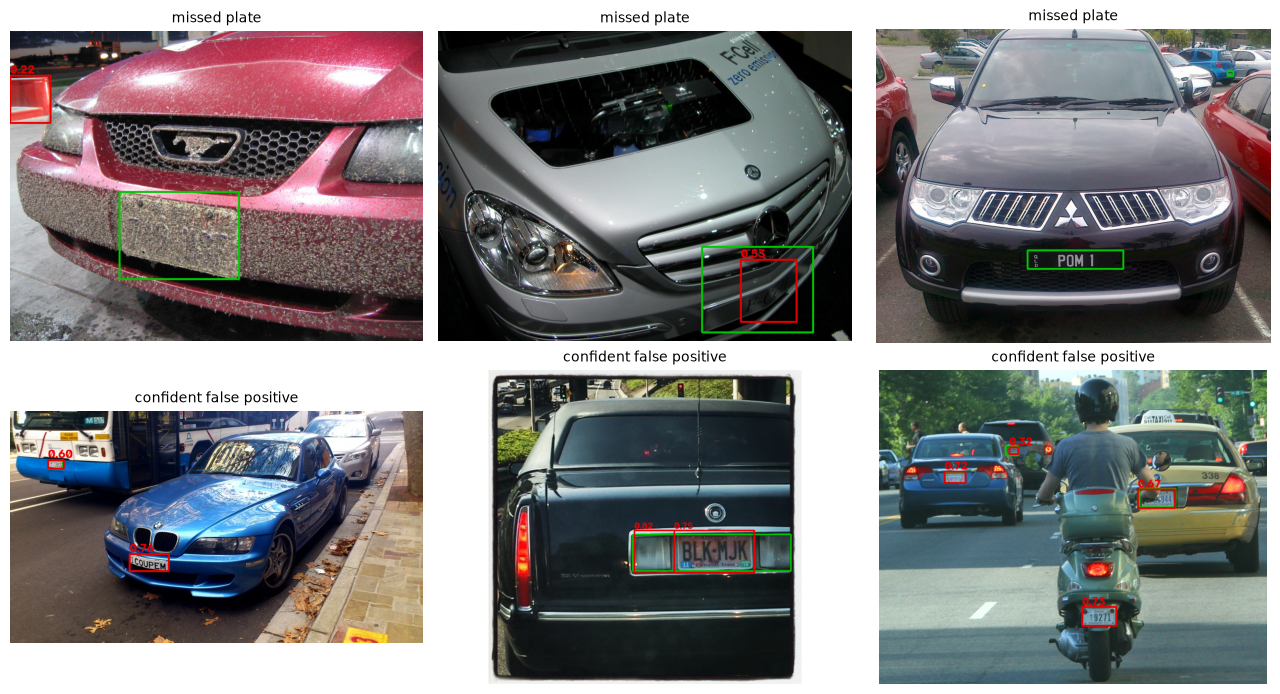

Test images with >=1 missed plate: 44 / 386 | with >=1 false positive: 58 / 386


In [12]:
def draw(stem, split="test"):
    p = preds[split][stem]
    img = cv2.cvtColor(cv2.imread(str(DATA_ROOT / "images" / split / f"{stem}.jpg")), cv2.COLOR_BGR2RGB)
    lw = max(2, img.shape[1] // 300)
    for x1, y1, x2, y2 in p["gt"].astype(int):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 200, 0), lw)
    for (x1, y1, x2, y2), c in zip(p["pred"].astype(int), p["conf"]):
        if c >= CONF:
            cv2.rectangle(img, (x1, y1), (x2, y2), (230, 0, 0), lw)
            cv2.putText(img, f"{c:.2f}", (x1, max(y1 - 5, 15)), cv2.FONT_HERSHEY_SIMPLEX, lw / 3, (230, 0, 0), lw)
    return img


missed, false_pos = [], []
for stem, p in preds["test"].items():
    tp, gt_conf = match(p["pred"], p["conf"], p["gt"])
    if (gt_conf < CONF).any():
        missed.append((p["gt_w_in"][gt_conf < CONF].max(), stem))      # prefer larger missed plates (more informative)
    fp_conf = p["conf"][(~tp) & (p["conf"] >= CONF)]
    if len(fp_conf):
        false_pos.append((fp_conf.max(), stem))

examples = [s for _, s in sorted(missed, reverse=True)[:3]] + [s for _, s in sorted(false_pos, reverse=True)[:3]]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, stem, title in zip(axes.flat, examples, ["missed plate"] * 3 + ["confident false positive"] * 3):
    ax.imshow(draw(stem)); ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()
print(f"Test images with >=1 missed plate: {len(missed)} / {len(preds['test'])} | "
      f"with >=1 false positive: {len(false_pos)} / {len(preds['test'])}")

## 9. Anonymisation: blurring only inside the detected box *(Business Q8)*

For each detection the pipeline:
1. **Takes the box in pixel coordinates** (`x1, y1, x2, y2`; Ultralytics already returns them in original-image pixels).
2. **Pads it by a margin** (a % of the box size) to absorb localisation error. A box that is a few pixels too tight would leave the edge characters readable (mAP@50-95 in 8.1 shows boxes are not pixel-perfect).
3. **Clips it to the image borders** and converts to integers, since NumPy slicing needs valid integer indices.
4. **Slices the region of interest** `roi = img[y1:y2, x1:x2]`. NumPy indexes rows (y) first, then columns (x).
5. **Applies a Gaussian blur to the ROI only** and writes it back into the same slice. Everything outside the box is untouched, so the rest of the frame (vehicle type, traffic density, scene) keeps its analytical value.
6. **Scales the blur kernel with the plate size.** A fixed 15x15 kernel destroys a tiny far-away plate but barely softens a large close-up one; a kernel proportional to the plate width gives the *same* level of anonymisation at every distance. (The kernel must be odd for OpenCV.)

In [13]:
def expand_and_clip(box, pad_ratio, img_w, img_h):
    """Grow a pixel box by pad_ratio of its size on every side, clip to the image, return ints."""
    x1, y1, x2, y2 = box
    pw, ph = (x2 - x1) * pad_ratio, (y2 - y1) * pad_ratio
    return (int(max(0, np.floor(x1 - pw))), int(max(0, np.floor(y1 - ph))),
            int(min(img_w, np.ceil(x2 + pw))), int(min(img_h, np.ceil(y2 + ph))))


def blur_regions(img, boxes, pad_ratio=0.1, kernel_frac=0.5):
    """Gaussian-blur only inside each box; the kernel size is kernel_frac x the box's longest side."""
    out = img.copy()
    img_h, img_w = img.shape[:2]
    for box in boxes:
        x1, y1, x2, y2 = expand_and_clip(box, pad_ratio, img_w, img_h)
        if x2 - x1 < 2 or y2 - y1 < 2:
            continue
        roi = out[y1:y2, x1:x2]
        k = max(3, int(max(roi.shape[:2]) * kernel_frac) | 1)          # odd kernel size
        out[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (k, k), 0)
    return out


def anonymise(img, conf=None, pad_ratio=0.1, kernel_frac=0.5):
    """Detect plates in a BGR image and return (blurred image, boxes)."""
    r = model.predict(img, imgsz=IMGSZ, conf=conf or CONF, device=DEVICE, verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    return blur_regions(img, boxes, pad_ratio, kernel_frac), boxes

### 9.1 How strong must the blur be? *(blur consistency)*

The blur has to make the characters unreadable (including by OCR engines) while staying confined to the plate. As a quantitative proxy for readability, the **variance of the Laplacian** (edge/detail energy) inside each labelled test plate is compared before and after blurring. Lower retained detail means less legible text. Labelled boxes are used here so that only the blur strength is measured, not detection errors.

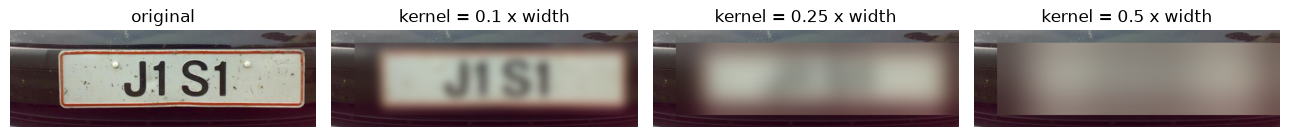

,plates,median detail retained,95th pct retained,worst case
kernel = 0.1 x plate width,511.0,0.014,0.198,0.352
kernel = 0.25 x plate width,511.0,0.002,0.066,0.200
kernel = 0.5 x plate width,511.0,0.001,0.016,0.054


In [14]:
def sharpness(gray):
    return cv2.Laplacian(gray, cv2.CV_64F).var()


KERNEL_FRACS = [0.1, 0.25, 0.5]
retained = {k: [] for k in KERNEL_FRACS}
for stem, p in preds["test"].items():
    img = cv2.imread(str(DATA_ROOT / "images" / "test" / f"{stem}.jpg"))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    for box in p["gt"]:
        x1, y1, x2, y2 = expand_and_clip(box, 0, img.shape[1], img.shape[0])
        if (x2 - x1) < 8 or (y2 - y1) < 4:
            continue
        before = sharpness(gray[y1:y2, x1:x2])
        if before < 1:
            continue
        for k in KERNEL_FRACS:
            blurred = cv2.cvtColor(blur_regions(img[y1:y2, x1:x2], [(0, 0, x2 - x1, y2 - y1)], 0, k), cv2.COLOR_BGR2GRAY)
            retained[k].append(sharpness(blurred) / before)

blur_strength = pd.DataFrame({f"kernel = {k:g} x plate width": pd.Series(v).describe(percentiles=[.5, .95])[["count", "50%", "95%", "max"]]
                              for k, v in retained.items()}).T
blur_strength.columns = ["plates", "median detail retained", "95th pct retained", "worst case"]

# Visual check on the largest test plate (the hardest one to hide)
stem, box = max(((s, b) for s, p in preds["test"].items() for b in p["gt"]), key=lambda sb: sb[1][2] - sb[1][0])
img = cv2.imread(str(DATA_ROOT / "images" / "test" / f"{stem}.jpg"))
x1, y1, x2, y2 = expand_and_clip(box, 0.3, img.shape[1], img.shape[0])
fig, axes = plt.subplots(1, 4, figsize=(13, 2.6))
axes[0].imshow(cv2.cvtColor(img[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)); axes[0].set_title("original")
for ax, k in zip(axes[1:], KERNEL_FRACS):
    ax.imshow(cv2.cvtColor(blur_regions(img, [box], 0.1, k)[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))
    ax.set_title(f"kernel = {k:g} x width")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()
blur_strength.round(3)

### 9.2 Privacy check: how many labelled plates actually end up blurred?

Detection metrics (8.1) score boxes; what the business cares about is whether **each real plate is covered by blur**. A labelled plate is counted as *anonymised* only if at least 95% of its area falls inside the blurred (padded) regions. This shows how much the padding margin closes the gap left by imperfect localisation. The last column is the price paid: the average share of each image that gets blurred (labelled plates cover only a few % of the image, so anything far above that means non-plate content is being destroyed).

In [15]:
def coverage_per_plate(p, conf, pad_ratio):
    """Fraction of each labelled plate's area covered by the padded, kept detections, plus the blurred share of the image."""
    h, w = p["shape"]
    mask = np.zeros((h, w), bool)
    for box in p["pred"][p["conf"] >= conf]:
        x1, y1, x2, y2 = expand_and_clip(box, pad_ratio, w, h)
        mask[y1:y2, x1:x2] = True
    cov = []
    for box in p["gt"]:
        x1, y1, x2, y2 = expand_and_clip(box, 0, w, h)
        cov.append(mask[y1:y2, x1:x2].mean() if (x2 > x1 and y2 > y1) else 1.0)
    return cov, mask.mean()


PADS = [0.0, 0.05, 0.1, 0.2]
rows = []
for pad in PADS:
    per_image = [coverage_per_plate(p, CONF, pad) for p in preds["test"].values()]
    cov = np.concatenate([c for c, _ in per_image])
    rows.append({"pad_ratio": pad, "plates_anonymised_%": 100 * (cov >= 0.95).mean(),
                 "partially_covered_%": 100 * ((cov > 0) & (cov < 0.95)).mean(),
                 "fully_missed_%": 100 * (cov == 0).mean(),
                 "image_area_blurred_%": 100 * np.mean([a for _, a in per_image])})
privacy = pd.DataFrame(rows).set_index("pad_ratio")
privacy.round(1)

,plates_anonymised_%,partially_covered_%,fully_missed_%,image_area_blurred_%
pad_ratio,,,,
0.00,56.1,35.4,8.6,1.9
0.05,80.5,10.9,8.6,2.2
0.10,85.0,6.4,8.6,2.6
0.20,89.3,2.1,8.6,3.6


### 9.3 End-to-end pipeline on the test set: output and speed

Every test image is run through *detect, then blur*, using the settings chosen above: confidence threshold from 8.2, **20% padding** (9.2: +4 points of fully anonymised plates for ~1% more blurred area than 10% padding) and a kernel of **0.5x plate width** (9.1); the anonymised copies are written to `outputs/blurred_test/`. Timings are measured per frame to judge whether the pipeline keeps up with a live video stream (25-30 FPS).

images                      386.00
plates blurred              531.00
detect ms/frame (median)     17.25
blur ms/frame (median)        5.30
pipeline FPS                 44.34


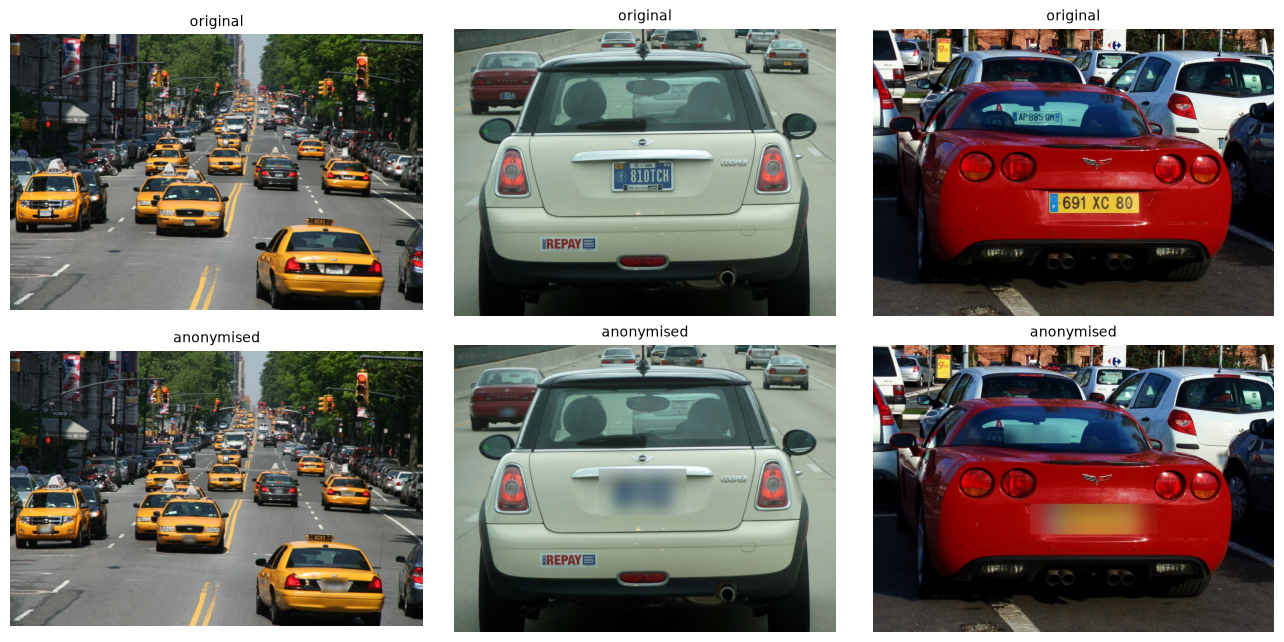

In [16]:
PAD, KERNEL_FRAC = 0.2, 0.5   # chosen from the privacy table (9.2) and blur-strength test (9.1)
blur_dir = OUT_DIR / "blurred_test"
blur_dir.mkdir(parents=True, exist_ok=True)

t_detect, t_blur, n_plates = [], [], 0
for path in test_paths:
    img = cv2.imread(str(path))
    if DEVICE != "cpu": torch.cuda.synchronize()
    t0 = time.perf_counter()
    r = model.predict(img, imgsz=IMGSZ, conf=CONF, device=DEVICE, verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    t1 = time.perf_counter()
    out = blur_regions(img, boxes, PAD, KERNEL_FRAC)
    t2 = time.perf_counter()
    cv2.imwrite(str(blur_dir / path.name), out)
    t_detect.append(t1 - t0); t_blur.append(t2 - t1); n_plates += len(boxes)

det_ms, blur_ms = 1000 * np.median(t_detect), 1000 * np.median(t_blur)
pipeline = pd.Series({"images": len(test_paths), "plates blurred": n_plates,
                      "detect ms/frame (median)": det_ms, "blur ms/frame (median)": blur_ms,
                      "pipeline FPS": 1000 / (det_ms + blur_ms)}).round(2)
print(pipeline.to_string())

# Before / after on test images with several plates
multi = sorted(preds["test"], key=lambda s: len(preds["test"][s]["gt"]), reverse=True)[:3]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for i, stem in enumerate(multi):
    before = cv2.imread(str(DATA_ROOT / "images" / "test" / f"{stem}.jpg"))
    after = cv2.imread(str(blur_dir / f"{stem}.jpg"))
    axes[0, i].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB)); axes[0, i].set_title("original", fontsize=10)
    axes[1, i].imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB)); axes[1, i].set_title("anonymised", fontsize=10)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [17]:
# Key numbers, saved so the write-up can be done without a GPU
summary = {
    "model": RUN_NAME, "imgsz": IMGSZ, "conf_threshold": CONF, "pad_ratio": PAD, "kernel_frac": KERNEL_FRAC,
    "train_hours": round(train_hours, 2), "epochs_run": int(len(results)),
    "metrics": detection_metrics.round(4).to_dict(orient="index"),
    "test_recall_by_size": by_size.round(4).reset_index().astype({"size": str}).to_dict(orient="records"),
    "privacy_by_pad": privacy.round(2).reset_index().to_dict(orient="records"),
    "pipeline": pipeline.to_dict(),
    "variants": variants.round(2).reset_index().to_dict(orient="records"),
}
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=float))
print(json.dumps({k: summary[k] for k in ["conf_threshold", "metrics", "pipeline"]}, indent=2, default=float))

{
  "conf_threshold": 0.2,
  "metrics": {
    "val": {
      "precision": 0.8737,
      "recall": 0.8226,
      "mAP@50": 0.8618,
      "mAP@50-95": 0.4688,
      "inference_ms/img": 3.2424,
      "total_ms/img": 5.397
    },
    "test": {
      "precision": 0.9176,
      "recall": 0.8926,
      "mAP@50": 0.915,
      "mAP@50-95": 0.661,
      "inference_ms/img": 3.614,
      "total_ms/img": 5.569
    }
  },
  "pipeline": {
    "images": 386.0,
    "plates blurred": 531.0,
    "detect ms/frame (median)": 17.25,
    "blur ms/frame (median)": 5.3,
    "pipeline FPS": 44.34
  }
}


## 10. Insights & Recommendations

### Results at a glance (YOLOv8s, 640 px, 30 epochs, conf = 0.20, padding = 20%)

| | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---|---|---|---|
| Validation (1,073 images) | 0.874 | 0.823 | 0.862 | 0.469 |
| **Test (386 images, held out)** | **0.918** | **0.893** | **0.915** | **0.661** |

* **Privacy:** 89% of the labelled test plates are fully (>= 95%) covered by blur and a further 2% partially; 8.6% are missed by the detector.
* **Cost to image utility:** only ~3.6% of each image's area is blurred on average.
* **Speed:** detect + blur runs at **~44 FPS** end to end on an RTX 3070 (~17 ms detection + ~5 ms blur), above the 25-30 FPS needed for live video.

### Key insights

1. **Plate size, not model size, is the main factor in performance.** Test recall is **98%** for plates >= 64 px wide but only **53%** for plates < 16 px (8.3). This also explains why test scores are higher than validation scores: test plates are about twice as large (median 71 px vs. 33 px).
2. **Train/validation domain gap.** The dataset merges two sources. 83% of the training images are Roboflow close-ups, while validation and test are entirely Open Images street scenes. Mosaic and scale augmentation partly close this gap by shrinking the close-up plates during training.
3. **Annotation quality limits both the score and the blur (Business Q3).** The error analysis (8.4) shows that many "confident false positives" are **real plates that were never labelled** (e.g. "COUPEM", the scooter and taxi plates), so the measured precision is *understated*. Several "misses" are **loose labelled boxes** that include headlights or bumper, so a correct, tight prediction fails the IoU >= 0.5 test. Loose and inconsistent boxes also teach the model fuzzy plate boundaries, which keeps mAP@50-95 low (0.47 on validation). For blurring this means boxes cannot be trusted to the pixel, which is why padding was needed: **without padding only 56% of plates are fully covered; 20% padding raises that to 89%** (9.2).
4. **mAP@50-95 understates usefulness for anonymisation.** A box that is a few pixels off counts as wrong at strict IoU thresholds, yet with padding it still hides the plate. The **coverage-based privacy rate (9.2) is the metric that matters to the business**, alongside recall.
5. **Threshold choice is a business decision.** With the default 0.25 threshold, 56 test plates are missed; with 0.20 (chosen on validation by F2, which favours recall), 51; and with 0.50, 86. Lowering the threshold costs only a few extra false blurs.
6. **Blur strength must scale with plate size.** A kernel of 0.1x the plate width leaves up to 35% of the edge detail, so large plates stay legible. A kernel of 0.5x the plate width retains at most ~5% even in the worst case, so the text is unreadable at every distance (9.1).

### Recommendations

1. **Deploy as a mandatory pre-storage step**: run anonymisation before footage reaches cloud storage, with `conf = 0.20`, `padding = 20%` and `kernel = 0.5 x plate width`.
2. **Target small plates next**: train and run inference at 960-1024 px, or tile wide-angle frames (e.g. SAHI) for traffic cameras, and add more Open Images-style street scenes to training. According to 8.3, this is where the remaining privacy leaks are.
3. **Fix the labels**: re-annotate the unlabelled plates in validation and test so the metrics are trustworthy, and adopt a "tight box around the plate only" labelling guideline.
4. **Human-in-the-loop learning**: send detections in the 0.05-0.20 confidence band (rain, night, partial occlusion) to human review and add them back to the training set.
5. **Edge deployment**: export to ONNX/TensorRT (FP16) for camera-side processing. On CPU-only devices, consider *n* (~23 FPS) and accept lower recall, or *s* at a reduced frame rate.
6. **Video-specific safeguards**: carry boxes across frames (tracking or temporal smoothing) so that a single missed frame does not briefly expose a plate, and spot-check blurred output with an OCR engine as an automated quality gate.